# E-Commerce Sales & Customer Analytics
## 04 — Customer Analytics

This notebook builds the **customer-level analytical layer** for the E-Commerce Sales & Customer Analytics project.

### Objectives
- Build a reliable customer-level dataset from the validated transaction data
- Measure customer revenue, order frequency, units, and average order value
- Identify repeat and one-time customers
- Analyze customer revenue concentration
- Compare customer performance by country
- Calculate and score **RFM (Recency, Frequency, Monetary)** metrics
- Assign business-oriented customer segments
- Analyze segment size and revenue contribution
- Export the final customer-level RFM dataset for Power BI

### Data principle
`../data/cleaned_sales.csv` remains the authoritative transaction dataset. Transactions without a Customer ID are retained in the transaction layer but excluded from **individual customer attribution** because they cannot be reliably assigned to a customer.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")


## 1. Load Final Transaction Dataset

In [3]:
cleaned_path = "../data/cleaned_sales.csv"

df_sales = pd.read_csv(
    cleaned_path,
    parse_dates=["invoicedate"]
)

df_sales["customer_id"] = pd.to_numeric(
    df_sales["customer_id"],
    errors="coerce"
)

print("Dataset loaded successfully.")
print("Rows:", f"{len(df_sales):,}")
print("Columns:", len(df_sales.columns))
print("Date range:", df_sales["invoicedate"].min(), "to", df_sales["invoicedate"].max())


Dataset loaded successfully.
Rows: 993,401
Columns: 10
Date range: 2009-12-01 07:45:00 to 2011-12-09 12:50:00


## 2. Validate the Customer Analysis Input

The checks below confirm that the customer analysis is based on the same finalized transaction layer used by the rest of the project.


In [4]:
required_columns = [
    "invoice", "stockcode", "description", "quantity",
    "invoicedate", "price", "customer_id",
    "country", "is_cancelled", "revenue"
]

missing_columns = [c for c in required_columns if c not in df_sales.columns]

print("CUSTOMER ANALYSIS VALIDATION")
print("=" * 45)
print("Missing required columns:", missing_columns if missing_columns else "None")
print("Rows:", f"{len(df_sales):,}")
print("Missing Customer IDs:", f"{df_sales['customer_id'].isna().sum():,}")
print("Cancelled rows:", f"{df_sales['is_cancelled'].sum():,}")
print("Zero-price rows:", f"{(df_sales['price'] == 0).sum():,}")
print("Duplicate rows:", f"{df_sales.duplicated().sum():,}")
print("Unique invoices:", f"{df_sales['invoice'].nunique():,}")
print("Total revenue:", f"£{df_sales['revenue'].sum():,.2f}")


CUSTOMER ANALYSIS VALIDATION
Missing required columns: None
Rows: 993,401
Missing Customer IDs: 224,593
Cancelled rows: 0
Zero-price rows: 0
Duplicate rows: 0
Unique invoices: 39,492
Total revenue: £19,433,661.76


## 3. Prepare Customer-Level Transactions

Customer-level metrics use only transactions with a valid Customer ID. Anonymous transactions remain in `df_sales` and are not silently attributed to any customer.


In [5]:
customer_df = df_sales.loc[
    df_sales["customer_id"].notna()
].copy()

customer_df["customer_id"] = customer_df["customer_id"].astype(int)

print("Customer-level transactions:", f"{len(customer_df):,}")
print("Identified customers:", f"{customer_df['customer_id'].nunique():,}")
print("Excluded anonymous transactions:", f"{len(df_sales) - len(customer_df):,}")
print("Identified customer revenue:", f"£{customer_df['revenue'].sum():,.2f}")


Customer-level transactions: 768,808
Identified customers: 5,851
Excluded anonymous transactions: 224,593
Identified customer revenue: £16,891,178.14


## 4. Customer-Level Summary

Each customer is represented by one row containing revenue, purchase frequency, units, order value, and purchase dates.


In [6]:
customer_summary = (
    customer_df
    .groupby("customer_id")
    .agg(
        total_revenue=("revenue", "sum"),
        total_orders=("invoice", "nunique"),
        total_units=("quantity", "sum"),
        first_purchase=("invoicedate", "min"),
        last_purchase=("invoicedate", "max")
    )
    .reset_index()
)

customer_summary["average_order_value"] = (
    customer_summary["total_revenue"] /
    customer_summary["total_orders"]
)

customer_summary = customer_summary.sort_values(
    "total_revenue",
    ascending=False
)

customer_summary.head(10)


,customer_id,total_revenue,total_orders,total_units,first_purchase,last_purchase,average_order_value
5665,18102,"573,427.32",145,176593,2009-12-01 09:24:00,2011-12-09 11:50:00,"3,954.67"
2262,14646,"523,944.57",145,365991,2009-12-02 16:52:00,2011-12-08 12:12:00,"3,613.41"
1778,14156,"298,257.33",143,162174,2009-12-01 12:30:00,2011-11-30 10:54:00,"2,085.72"
2520,14911,"270,349.47",373,146885,2009-12-01 11:41:00,2011-12-08 15:54:00,724.80
5025,17450,"232,357.52",51,81061,2010-09-27 16:59:00,2011-12-01 13:29:00,"4,556.03"
1321,13694,"193,571.56",143,186628,2009-12-04 15:26:00,2011-12-06 09:32:00,"1,353.65"
5084,17511,"171,114.31",60,116598,2009-12-02 10:52:00,2011-12-07 10:12:00,"2,851.91"
4037,16446,"168,472.50",2,80997,2011-05-18 09:52:00,2011-12-09 09:15:00,"84,236.25"
4271,16684,"145,555.17",55,104054,2009-12-07 12:56:00,2011-12-05 14:06:00,"2,646.46"
67,12415,"141,726.22",24,90782,2010-06-30 08:30:00,2011-11-15 14:22:00,"5,905.26"


In [7]:
print("CUSTOMER SUMMARY KPIs")
print("=" * 45)
print("Customers:", f"{len(customer_summary):,}")
print("Identified revenue:", f"£{customer_summary['total_revenue'].sum():,.2f}")
print("Average revenue per identified customer:",
      f"£{customer_summary['total_revenue'].mean():,.2f}")
print("Average orders per customer:",
      f"{customer_summary['total_orders'].mean():,.2f}")
print("Median orders per customer:",
      f"{customer_summary['total_orders'].median():,.0f}")
print("Average customer AOV:",
      f"£{customer_summary['average_order_value'].mean():,.2f}")


CUSTOMER SUMMARY KPIs
Customers: 5,851
Identified revenue: £16,891,178.14
Average revenue per identified customer: £2,886.89
Average orders per customer: 6.25
Median orders per customer: 3
Average customer AOV: £377.54


## 5. Purchase Frequency & Repeat Customers

Customers with more than one distinct invoice are classified as repeat customers for this analysis.


In [8]:
purchase_frequency = (
    customer_df
    .groupby("customer_id")
    .agg(
        total_orders=("invoice", "nunique"),
        total_revenue=("revenue", "sum")
    )
    .reset_index()
    .sort_values("total_orders", ascending=False)
)

repeat_customers = purchase_frequency[
    purchase_frequency["total_orders"] > 1
]

one_time_customers = purchase_frequency[
    purchase_frequency["total_orders"] == 1
]

total_customers = len(purchase_frequency)

print("PURCHASE FREQUENCY")
print("=" * 45)
print("Total identified customers:", f"{total_customers:,}")
print("Repeat customers:", f"{len(repeat_customers):,}")
print("One-time customers:", f"{len(one_time_customers):,}")
print("Repeat customer rate:",
      f"{len(repeat_customers) / total_customers * 100:.2f}%")
print("One-time customer rate:",
      f"{len(one_time_customers) / total_customers * 100:.2f}%")


PURCHASE FREQUENCY
Total identified customers: 5,851
Repeat customers: 4,233
One-time customers: 1,618
Repeat customer rate: 72.35%
One-time customer rate: 27.65%


In [9]:
frequency_distribution = (
    purchase_frequency["total_orders"]
    .value_counts()
    .sort_index()
)

frequency_distribution.head(20)


total_orders
1     1618
2      947
3      656
4      489
5      356
6      279
7      215
8      175
9      154
10      98
11     126
12      95
13      81
14      49
15      51
16      39
17      40
18      34
19      24
20      35
Name: count, dtype: int64

## 6. Top Customers by Revenue

In [10]:
top_customers = (
    customer_summary[
        [
            "customer_id",
            "total_revenue",
            "total_orders",
            "total_units",
            "average_order_value",
            "first_purchase",
            "last_purchase"
        ]
    ]
    .head(20)
)

top_customers


,customer_id,total_revenue,total_orders,total_units,average_order_value,first_purchase,last_purchase
5665,18102,"573,427.32",145,176593,"3,954.67",2009-12-01 09:24:00,2011-12-09 11:50:00
2262,14646,"523,944.57",145,365991,"3,613.41",2009-12-02 16:52:00,2011-12-08 12:12:00
1778,14156,"298,257.33",143,162174,"2,085.72",2009-12-01 12:30:00,2011-11-30 10:54:00
2520,14911,"270,349.47",373,146885,724.80,2009-12-01 11:41:00,2011-12-08 15:54:00
5025,17450,"232,357.52",51,81061,"4,556.03",2010-09-27 16:59:00,2011-12-01 13:29:00
1321,13694,"193,571.56",143,186628,"1,353.65",2009-12-04 15:26:00,2011-12-06 09:32:00
5084,17511,"171,114.31",60,116598,"2,851.91",2009-12-02 10:52:00,2011-12-07 10:12:00
4037,16446,"168,472.50",2,80997,"84,236.25",2011-05-18 09:52:00,2011-12-09 09:15:00
4271,16684,"145,555.17",55,104054,"2,646.46",2009-12-07 12:56:00,2011-12-05 14:06:00
67,12415,"141,726.22",24,90782,"5,905.26",2010-06-30 08:30:00,2011-11-15 14:22:00


## 7. Customer Revenue Concentration

Revenue concentration is calculated against **identifiable customer revenue**, not anonymous transaction revenue.


In [11]:
total_customer_revenue = customer_summary["total_revenue"].sum()

concentration_rows = []

for n in [1, 5, 10, 20]:
    revenue_n = customer_summary.head(n)["total_revenue"].sum()
    concentration_rows.append({
        "customer_count": n,
        "revenue": revenue_n,
        "revenue_share_pct": revenue_n / total_customer_revenue * 100
    })

revenue_concentration = pd.DataFrame(concentration_rows)

revenue_concentration


,customer_count,revenue,revenue_share_pct
0,1,"573,427.32",3.39
1,5,"1,898,336.21",11.24
2,10,"2,718,775.97",16.10
3,20,"3,713,531.31",21.99


## 8. Geographic Customer Analysis

This section evaluates countries using identified customers only, so customer counts and revenue-per-customer calculations have a consistent denominator.


In [12]:
country_analysis = (
    customer_df
    .groupby("country")
    .agg(
        customers=("customer_id", "nunique"),
        revenue=("revenue", "sum"),
        orders=("invoice", "nunique"),
        units=("quantity", "sum")
    )
    .reset_index()
)

country_analysis["revenue_per_customer"] = (
    country_analysis["revenue"] /
    country_analysis["customers"]
)

country_analysis["revenue_share_pct"] = (
    country_analysis["revenue"] /
    country_analysis["revenue"].sum() * 100
)

country_analysis = country_analysis.sort_values(
    "revenue",
    ascending=False
)

country_analysis.head(20)


,country,customers,revenue,orders,units,revenue_per_customer,revenue_share_pct
38,United Kingdom,5334,"14,142,205.72",33342,8450925,"2,651.33",83.73
10,EIRE,3,"579,698.11",527,314749,"193,232.70",3.43
24,Netherlands,22,"546,880.56",216,382502,"24,858.21",3.24
14,Germany,107,"378,012.16",751,220781,"3,532.82",2.24
13,France,93,"305,508.63",590,267267,"3,285.04",1.81
0,Australia,15,"165,453.26",89,103084,"11,030.22",0.98
32,Spain,38,"97,280.46",144,49699,"2,560.01",0.58
34,Switzerland,22,"92,607.38",82,51697,"4,209.43",0.55
33,Sweden,19,"84,537.04",98,87899,"4,449.32",0.50
9,Denmark,12,"67,276.89",42,237322,"5,606.41",0.40


In [13]:
top_countries = country_analysis.head(10).copy()

top_countries[
    [
        "country",
        "customers",
        "revenue",
        "orders",
        "units",
        "revenue_per_customer",
        "revenue_share_pct"
    ]
]


,country,customers,revenue,orders,units,revenue_per_customer,revenue_share_pct
38,United Kingdom,5334,"14,142,205.72",33342,8450925,"2,651.33",83.73
10,EIRE,3,"579,698.11",527,314749,"193,232.70",3.43
24,Netherlands,22,"546,880.56",216,382502,"24,858.21",3.24
14,Germany,107,"378,012.16",751,220781,"3,532.82",2.24
13,France,93,"305,508.63",590,267267,"3,285.04",1.81
0,Australia,15,"165,453.26",89,103084,"11,030.22",0.98
32,Spain,38,"97,280.46",144,49699,"2,560.01",0.58
34,Switzerland,22,"92,607.38",82,51697,"4,209.43",0.55
33,Sweden,19,"84,537.04",98,87899,"4,449.32",0.50
9,Denmark,12,"67,276.89",42,237322,"5,606.41",0.40


## 9. RFM Customer Segmentation

RFM evaluates customers using:

- **Recency:** days since the customer's most recent purchase
- **Frequency:** number of distinct orders
- **Monetary:** total customer revenue

A higher RFM score indicates stronger customer engagement/value.

For Recency, the scoring direction is reversed so that **more recent customers receive higher scores**.


In [14]:
analysis_date = df_sales["invoicedate"].max() + pd.Timedelta(days=1)

rfm = (
    customer_df
    .groupby("customer_id")
    .agg(
        recency=("invoicedate", lambda x: (analysis_date - x.max()).days),
        frequency=("invoice", "nunique"),
        monetary=("revenue", "sum")
    )
    .reset_index()
)

print("RFM analysis date:", analysis_date)
print("Customers scored:", f"{len(rfm):,}")

rfm.head()


RFM analysis date: 2011-12-10 12:50:00
Customers scored: 5,851


,customer_id,recency,frequency,monetary
0,12346,326,12,"77,556.46"
1,12347,2,8,"4,921.53"
2,12348,75,5,"1,658.40"
3,12349,19,3,"3,663.39"
4,12350,310,1,294.40


## 10. RFM Scoring

Five quantile groups are created for each dimension.

- Recency: labels **5 → 1** from most recent to least recent
- Frequency: labels **1 → 5** from lowest to highest
- Monetary: labels **1 → 5** from lowest to highest

Ranking is used before Frequency and Monetary quantiles to handle tied values consistently.


In [15]:
# ============================================================
# 10. RFM SCORING
# Match the final SQL NTILE(5) methodology
# ============================================================

import numpy as np

# ------------------------------------------------------------
# Helper function to reproduce SQL NTILE(5)
# ------------------------------------------------------------
def assign_ntile(df, column, ascending=True):
    """
    Reproduce SQL NTILE(5) using deterministic customer_id
    ordering for tied values.
    """

    sorted_df = df.sort_values(
        by=[column, "customer_id"],
        ascending=[ascending, True]
    ).copy()

    n = len(sorted_df)

    sorted_df["_position"] = np.arange(n)

    sorted_df[f"{column}_score"] = (
        np.floor(
            sorted_df["_position"] * 5 / n
        ).astype(int) + 1
    )

    return (
        sorted_df
        .drop(columns=["_position"])
    )


# ------------------------------------------------------------
# Recency Score
# Lower recency = more recent = higher score
#
# SQL:
# NTILE(5) OVER (
#     ORDER BY recency DESC
# )
# ------------------------------------------------------------

rfm = assign_ntile(
    rfm,
    "recency",
    ascending=False
)

rfm = rfm.rename(
    columns={
        "recency_score": "R_score"
    }
)


# ------------------------------------------------------------
# Frequency Score
# Higher frequency = higher score
#
# SQL:
# NTILE(5) OVER (
#     ORDER BY frequency ASC
# )
# ------------------------------------------------------------

rfm = assign_ntile(
    rfm,
    "frequency",
    ascending=True
)

rfm = rfm.rename(
    columns={
        "frequency_score": "F_score"
    }
)


# ------------------------------------------------------------
# Monetary Score
# Higher monetary value = higher score
#
# SQL:
# NTILE(5) OVER (
#     ORDER BY monetary ASC
# )
# ------------------------------------------------------------

rfm = assign_ntile(
    rfm,
    "monetary",
    ascending=True
)

rfm = rfm.rename(
    columns={
        "monetary_score": "M_score"
    }
)


# ------------------------------------------------------------
# Create numeric RFM score
# Example:
# R=5, F=4, M=5 → 545
# ------------------------------------------------------------

rfm["rfm_score"] = (
    rfm["R_score"] * 100
    + rfm["F_score"] * 10
    + rfm["M_score"]
)


# ------------------------------------------------------------
# Validation
# ------------------------------------------------------------

print("RFM scoring completed.")
print()

print("R score distribution:")
print(rfm["R_score"].value_counts().sort_index())

print()

print("F score distribution:")
print(rfm["F_score"].value_counts().sort_index())

print()

print("M score distribution:")
print(rfm["M_score"].value_counts().sort_index())

print()

print("RFM customers:", f"{len(rfm):,}")
print("Unique customers:", f"{rfm['customer_id'].nunique():,}")
print("Duplicate customer IDs:", rfm["customer_id"].duplicated().sum())
print("Missing customer IDs:", rfm["customer_id"].isna().sum())

RFM scoring completed.

R score distribution:
R_score
1    1171
2    1170
3    1170
4    1170
5    1170
Name: count, dtype: int64

F score distribution:
F_score
1    1171
2    1170
3    1170
4    1170
5    1170
Name: count, dtype: int64

M score distribution:
M_score
1    1171
2    1170
3    1170
4    1170
5    1170
Name: count, dtype: int64

RFM customers: 5,851
Unique customers: 5,851
Duplicate customer IDs: 0
Missing customer IDs: 0


## 11. Business Customer Segments

The segment definitions preserve the project's existing business terminology used in the customer analytics and Power BI layer.


In [23]:
def segment_customer(row):
    r = row["R_score"]
    f = row["F_score"]
    m = row["M_score"]

    if r >= 4 and f >= 4 and m >= 4:
        return "Champions"

    elif r >= 3 and f >= 4:
        return "Loyal Customers"

    elif r >= 4 and m >= 4 and f <= 2:
        return "Big Spenders"

    elif r >= 4 and 2 <= f <= 3:
        return "Potential Loyalists"

    elif r <= 2 and f >= 4:
        return "At Risk"

    elif r <= 2 and f <= 2 and m <= 2:
        return "Hibernating"

    elif r >= 4:
        return "Recent Customers"

    else:
        return "Needs Attention"


rfm["customer_segment"] = rfm.apply(
    segment_customer,
    axis=1
)

segment_counts = (
    rfm["customer_segment"]
    .value_counts()
    .rename_axis("customer_segment")
    .reset_index(name="customers")
)

segment_counts


,customer_segment,customers
0,Needs Attention,1360
1,Champions,1276
2,Hibernating,1273
3,Loyal Customers,703
4,Potential Loyalists,682
5,At Risk,361
6,Recent Customers,165
7,Big Spenders,31


## 12. RFM Segment Performance

Customer count is combined with revenue, revenue share, average revenue, frequency, and recency to provide a commercial view of each segment.


In [24]:
segment_analysis = (
    rfm
    .groupby("customer_segment")
    .agg(
        customers=("customer_id", "nunique"),
        revenue=("monetary", "sum"),
        avg_revenue=("monetary", "mean"),
        avg_frequency=("frequency", "mean"),
        avg_recency=("recency", "mean")
    )
    .reset_index()
)

segment_analysis["revenue_share_pct"] = (
    segment_analysis["revenue"] /
    segment_analysis["revenue"].sum() * 100
)

segment_analysis = segment_analysis.sort_values(
    "revenue",
    ascending=False
)

segment_analysis


,customer_segment,customers,revenue,avg_revenue,avg_frequency,avg_recency,revenue_share_pct
2,Champions,1276,"11,473,276.35","8,991.60",17.07,19.58,67.92
4,Loyal Customers,703,"1,819,477.69","2,588.16",7.67,82.79,10.77
5,Needs Attention,1360,"1,312,817.87",965.31,2.30,258.08,7.77
0,At Risk,361,"1,106,498.87","3,065.09",7.65,342.14,6.55
6,Potential Loyalists,682,"575,196.57",843.40,2.60,25.57,3.41
3,Hibernating,1273,"317,532.01",249.44,1.19,464.09,1.88
1,Big Spenders,31,"237,745.27","7,669.20",1.87,22.84,1.41
7,Recent Customers,165,"48,633.50",294.75,1.00,29.24,0.29


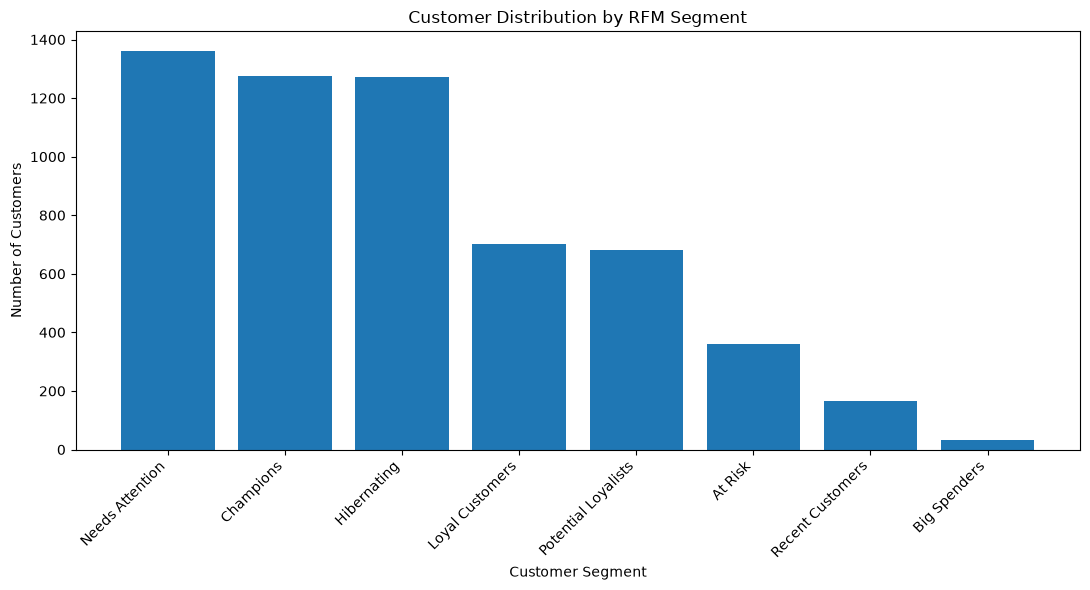

In [25]:
plt.figure(figsize=(11, 6))

plot_data = (
    segment_counts
    .sort_values("customers", ascending=False)
)

plt.bar(
    plot_data["customer_segment"],
    plot_data["customers"]
)

plt.title("Customer Distribution by RFM Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Number of Customers")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


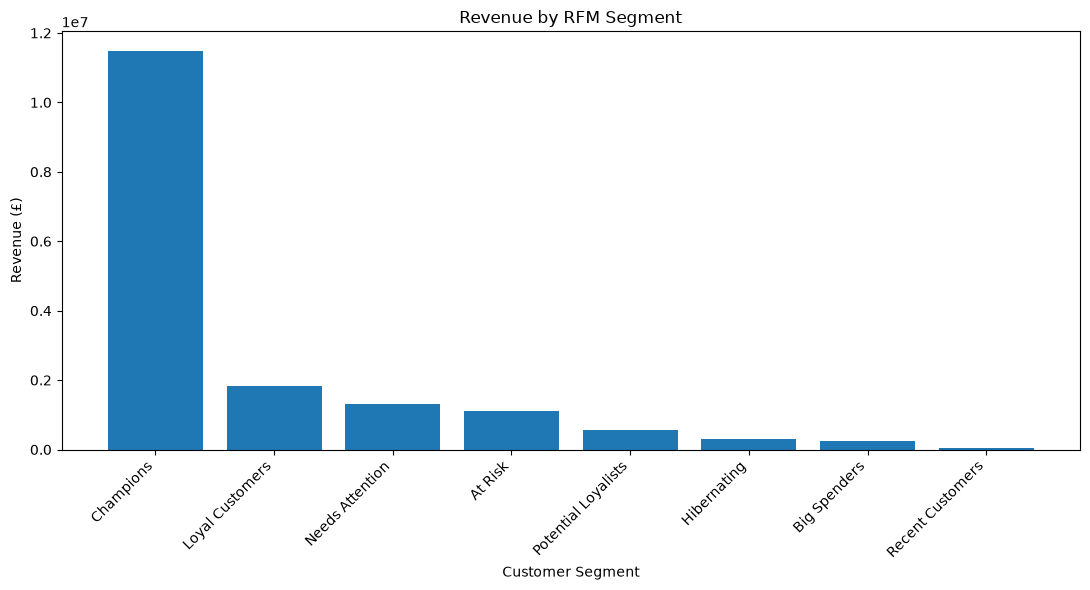

In [26]:
plt.figure(figsize=(11, 6))

plot_data = (
    segment_analysis
    .sort_values("revenue", ascending=False)
)

plt.bar(
    plot_data["customer_segment"],
    plot_data["revenue"]
)

plt.title("Revenue by RFM Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Revenue (£)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


## 13. Customer Segment Strategy

The analytical segments can be translated into practical customer-management actions.


In [27]:
segment_strategy = pd.DataFrame({
    "customer_segment": [
        "Champions",
        "Loyal Customers",
        "Big Spenders",
        "Potential Loyalists",
        "At Risk",
        "Hibernating",
        "Recent Customers",
        "Needs Attention"
    ],
    "recommended_action": [
        "Protect loyalty, personalize engagement, and encourage continued high-value purchasing.",
        "Use cross-sell, upsell, and loyalty incentives to strengthen retention.",
        "Use premium recommendations and personalized offers to protect high monetary value.",
        "Encourage repeat purchases and move promising customers toward loyal behavior.",
        "Prioritize targeted win-back campaigns and reactivation of previously purchased products.",
        "Use low-cost reactivation tests and monitor response before increasing spend.",
        "Build the second purchase through onboarding, recommendations, and timely follow-up.",
        "Use targeted nurturing and monitor behavior for movement into stronger segments."
    ]
})

segment_strategy


,customer_segment,recommended_action
0,Champions,"Protect loyalty, personalize engagement, and e..."
1,Loyal Customers,"Use cross-sell, upsell, and loyalty incentives..."
2,Big Spenders,Use premium recommendations and personalized o...
3,Potential Loyalists,Encourage repeat purchases and move promising ...
4,At Risk,Prioritize targeted win-back campaigns and rea...
5,Hibernating,Use low-cost reactivation tests and monitor re...
6,Recent Customers,"Build the second purchase through onboarding, ..."
7,Needs Attention,Use targeted nurturing and monitor behavior fo...


## 14. Executive Customer Insights

The following metrics provide the final customer-level summary used for reporting and documentation.


In [28]:
at_risk = rfm[rfm["customer_segment"] == "At Risk"]

executive_customer_summary = {
    "Identified Customers": int(rfm["customer_id"].nunique()),
    "Identified Customer Revenue": float(rfm["monetary"].sum()),
    "Average Revenue per Identified Customer": float(rfm["monetary"].mean()),
    "Repeat Customers": int(len(repeat_customers)),
    "One-Time Customers": int(len(one_time_customers)),
    "Repeat Customer Rate %": float(len(repeat_customers) / len(purchase_frequency) * 100),
    "Top 10 Customer Revenue": float(customer_summary.head(10)["total_revenue"].sum()),
    "Top 10 Revenue Share %": float(customer_summary.head(10)["total_revenue"].sum() / total_customer_revenue * 100),
    "At-Risk Customers": int(len(at_risk)),
    "At-Risk Revenue": float(at_risk["monetary"].sum()),
    "Countries with Identified Customers": int(country_analysis["country"].nunique())
}

for metric, value in executive_customer_summary.items():
    if "Revenue" in metric or "Customer" in metric and "%" not in metric:
        if isinstance(value, float) and value > 100:
            print(f"{metric}: £{value:,.2f}")
        else:
            print(f"{metric}: {value:,.0f}")
    elif "%" in metric:
        print(f"{metric}: {value:.2f}%")
    else:
        print(f"{metric}: {value:,.0f}")


Identified Customers: 5,851
Identified Customer Revenue: £16,891,178.14
Average Revenue per Identified Customer: £2,886.89
Repeat Customers: 4,233
One-Time Customers: 1,618
Repeat Customer Rate %: 72.35%
Top 10 Customer Revenue: £2,718,775.97
Top 10 Revenue Share %: 16
At-Risk Customers: 361
At-Risk Revenue: £1,106,498.87
Countries with Identified Customers: 41


## 15. Final RFM Dataset

The exported customer-level table combines behavioral metrics, RFM scores, and the business segment into one reusable analytical dataset.


In [29]:
rfm_export = rfm[
    [
        "customer_id",
        "recency",
        "frequency",
        "monetary",
        "R_score",
        "F_score",
        "M_score",
        "rfm_score",
        "customer_segment"
    ]
].copy()

rfm_export = rfm_export.sort_values(
    ["customer_segment", "monetary"],
    ascending=[True, False]
)

rfm_export.head(20)


,customer_id,recency,frequency,monetary,R_score,F_score,M_score,rfm_score,customer_segment
0,12346,326,12,"77,556.46",2,5,5,255,At Risk
4340,16754,372,29,"65,500.07",2,5,5,255,At Risk
734,13093,276,55,"54,083.05",2,5,5,255,At Risk
5415,17850,372,155,"50,605.63",2,5,5,255,At Risk
1527,13902,632,5,"34,023.26",1,4,5,145,At Risk
133,12482,576,27,"21,387.32",1,5,5,155,At Risk
3407,15808,306,21,"16,999.35",2,5,5,255,At Risk
1193,13564,354,36,"15,768.85",2,5,5,255,At Risk
5023,17448,529,41,"14,352.07",1,5,5,155,At Risk
5650,18087,291,16,"13,908.72",2,5,5,255,At Risk


## 16. Export Customer-Level RFM Dataset

In [30]:
rfm_path = "../data/customer_rfm.csv"

rfm_export.to_csv(
    rfm_path,
    index=False
)

print("RFM dataset exported successfully.")
print("Customers:", f"{len(rfm_export):,}")
print("Columns:", len(rfm_export.columns))
print("File:", rfm_path)


RFM dataset exported successfully.
Customers: 5,851
Columns: 9
File: ../data/customer_rfm.csv


## 17. Final Consistency Check

These checks confirm that the customer notebook has not modified the authoritative transaction layer and that the exported RFM table contains one row per identified customer.


In [31]:
print("FINAL CUSTOMER ANALYTICS CHECK")
print("=" * 50)

print("Transaction rows:", f"{len(df_sales):,}")
print("Transaction revenue:", f"£{df_sales['revenue'].sum():,.2f}")
print("Identified customers:", f"{df_sales['customer_id'].nunique():,}")
print("Customer-level rows:", f"{len(customer_summary):,}")
print("RFM rows:", f"{len(rfm_export):,}")
print("Unique RFM customers:", f"{rfm_export['customer_id'].nunique():,}")
print("RFM duplicate customer IDs:", f"{rfm_export['customer_id'].duplicated().sum():,}")
print("RFM missing customer IDs:", f"{rfm_export['customer_id'].isna().sum():,}")
print("Segmented customers:", f"{rfm_export['customer_segment'].notna().sum():,}")

print("\nTransaction layer unchanged:",
      len(df_sales) == 993401)

print("RFM one-row-per-customer:",
      len(rfm_export) == rfm_export["customer_id"].nunique())


FINAL CUSTOMER ANALYTICS CHECK
Transaction rows: 993,401
Transaction revenue: £19,433,661.76
Identified customers: 5,851
Customer-level rows: 5,851
RFM rows: 5,851
Unique RFM customers: 5,851
RFM duplicate customer IDs: 0
RFM missing customer IDs: 0
Segmented customers: 5,851

Transaction layer unchanged: True
RFM one-row-per-customer: True
